In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from string import punctuation
import pandas as pd
import joblib
import os
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)

In [50]:
df_eda = pd.read_csv('Symptom2Disease.csv')
df_eda.head()

,Unnamed: 0,label,text
0,0,Psoriasis,"I have been experiencing a skin rash on my arms, legs, and torso for the past few weeks. It is red, itchy, and covered in dry, scaly patches."
1,1,Psoriasis,"My skin has been peeling, especially on my knees, elbows, and scalp. This peeling is often accompanied by a burning or stinging sensation."
2,2,Psoriasis,"I have been experiencing joint pain in my fingers, wrists, and knees. The pain is often achy and throbbing, and it gets worse when I move my joints."
3,3,Psoriasis,"There is a silver like dusting on my skin, especially on my lower back and scalp. This dusting is made up of small scales that flake off easily when I scratch them."
4,4,Psoriasis,"My nails have small dents or pits in them, and they often feel inflammatory and tender to the touch. Even there are minor rashes on my arms."


In [51]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1200 non-null   int64 
 1   label       1200 non-null   object
 2   text        1200 non-null   object
dtypes: int64(1), object(2)
memory usage: 28.2+ KB


In [52]:
print(f"Unique diseases: {df_eda['label'].nunique()}")
print(f"Total samples: {len(df_eda)}")
print("\nSamples per disease:")
print(df_eda['label'].value_counts())

Unique diseases: 24
Total samples: 1200

Samples per disease:
label
Psoriasis                          50
Varicose Veins                     50
peptic ulcer disease               50
drug reaction                      50
gastroesophageal reflux disease    50
allergy                            50
urinary tract infection            50
Malaria                            50
Jaundice                           50
Cervical spondylosis               50
Migraine                           50
Hypertension                       50
Bronchial Asthma                   50
Acne                               50
Arthritis                          50
Dimorphic Hemorrhoids              50
Pneumonia                          50
Common Cold                        50
Fungal infection                   50
Dengue                             50
Impetigo                           50
Chicken pox                        50
Typhoid                            50
diabetes                           50
Name: count, dtype: 

In [53]:
print(df_eda['text'].sample(5).values)

["Lately I've been experiencing a skin rash with a lot of pus-filled pimples and blackheads. My skin has also been scurring a lot."
 "I'm suffering from intense itching, chills, vomiting, and a high fever. I've also been sweating a lot and have a headache. Nausea and muscle pain have also been bothering me."
 "Along with my intense scratching, chills, nausea, and high fever, I've also been feeling really unwell. Along with my headache and excessive sweating, I've been suffering from severe muscle pain and nausea."
 'I have developed rashes on my body. I am also experiencing high fever along with chills and headache. My joints and back hurt and there is a strange pain in the back of my eyes.'
 'Doctor, I have a really itchy rash on my skin and there are some weird spots that are a different color. There are also some bumps on my skin that look like little knots']


In [54]:
# It seems that the text is already clean, there are no anomalies like non-unicode characters. Means we continue with basic preprocessing

ENGLISH_STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def tag_to_wordnet(tag: str):
    if tag.startswith('J'):
        return wordnet.ADJ
    if tag.startswith('V'):
        return wordnet.VERB
    if tag.startswith('R'):
        return wordnet.ADV
    if tag.startswith('N'):
        return wordnet.NOUN
    return wordnet.NOUN

def preprocess_text(text: str):    
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t not in ENGLISH_STOPWORDS and t not in punctuation and t.isalpha()]
    
    tagged_tokens = pos_tag(tokens)
    lemmatized_tokens = [lemmatizer.lemmatize(token, tag_to_wordnet(tag)) for token, tag in tagged_tokens]
    
    return ' '.join(lemmatized_tokens)

In [55]:
df = pd.read_csv('Symptom2Disease.csv')
X = df['text']
y = df['label']


models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': MultinomialNB()
}

X_preprocessed = X.apply(preprocess_text)

X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

for name, clf in models.items():
    clf.fit(X_train_tfidf, y_train)
    y_pred = clf.predict(X_test_tfidf)
    print(f"{name}: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    
    new_text = "I've been sneezing a lot and my nose feels so clogged. I can't even smell anything!"
    new_preprocessed = preprocess_text(new_text)
    new_tfidf = vectorizer.transform([new_preprocessed])
    print(clf.predict(new_tfidf))


Random Forest: 0.9667
                                 precision    recall  f1-score   support

                           Acne       0.88      1.00      0.93         7
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        11
           Cervical spondylosis       1.00      1.00      1.00         7
                    Chicken pox       0.91      0.83      0.87        12
                    Common Cold       1.00      1.00      1.00        12
                         Dengue       0.92      1.00      0.96        12
          Dimorphic Hemorrhoids       1.00      1.00      1.00         7
               Fungal infection       1.00      0.92      0.96        13
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       0.92      1.00      0.96        11
                       Jaundice       1.00      1.00      1.00        11
                        Mala

In [56]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save each model separately
for name, clf in models.items():
    filename = f'models/{name.replace(" ", "_").lower()}.joblib'
    joblib.dump(clf, filename, compress=True)
    print(f"Saved: {filename}")

# Save vectorizer
joblib.dump(vectorizer, 'vectorizer.joblib', compress=True)
print("Vectorizer saved: vectorizer.joblib")
print("All models saved successfully!")

Saved: models/random_forest.joblib
Saved: models/logistic_regression.joblib
Saved: models/decision_tree.joblib
Saved: models/naive_bayes.joblib
Vectorizer saved: vectorizer.joblib
All models saved successfully!


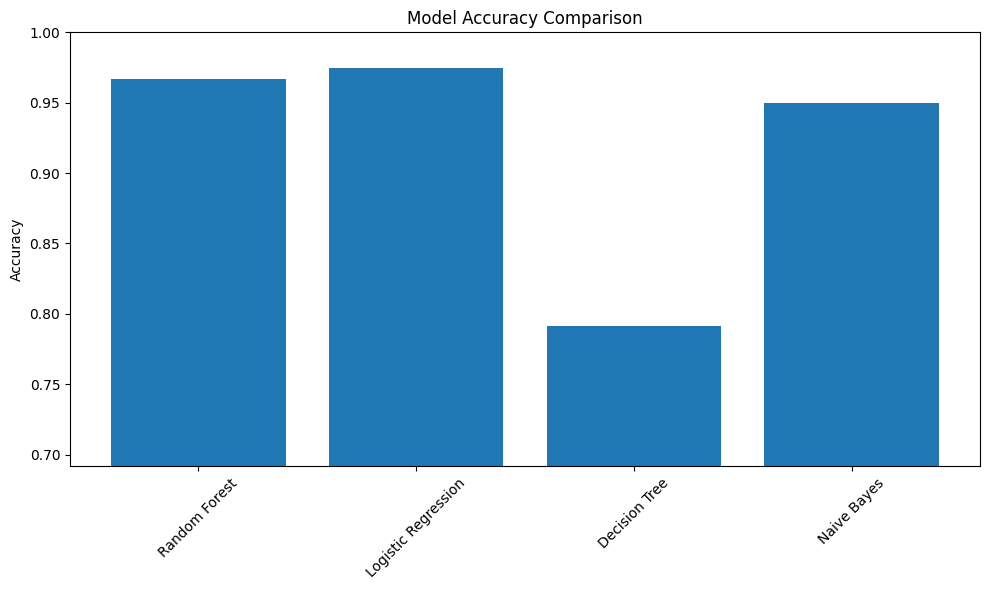

In [57]:
accuracies = {}
for name, clf in models.items():
    y_pred = clf.predict(X_test_tfidf)
    accuracies[name] = accuracy_score(y_test, y_pred)

plt.figure(figsize=(10, 6))
plt.bar(accuracies.keys(), accuracies.values())
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylim([min(accuracies.values()) - 0.1, 1])
plt.tight_layout()
plt.show()

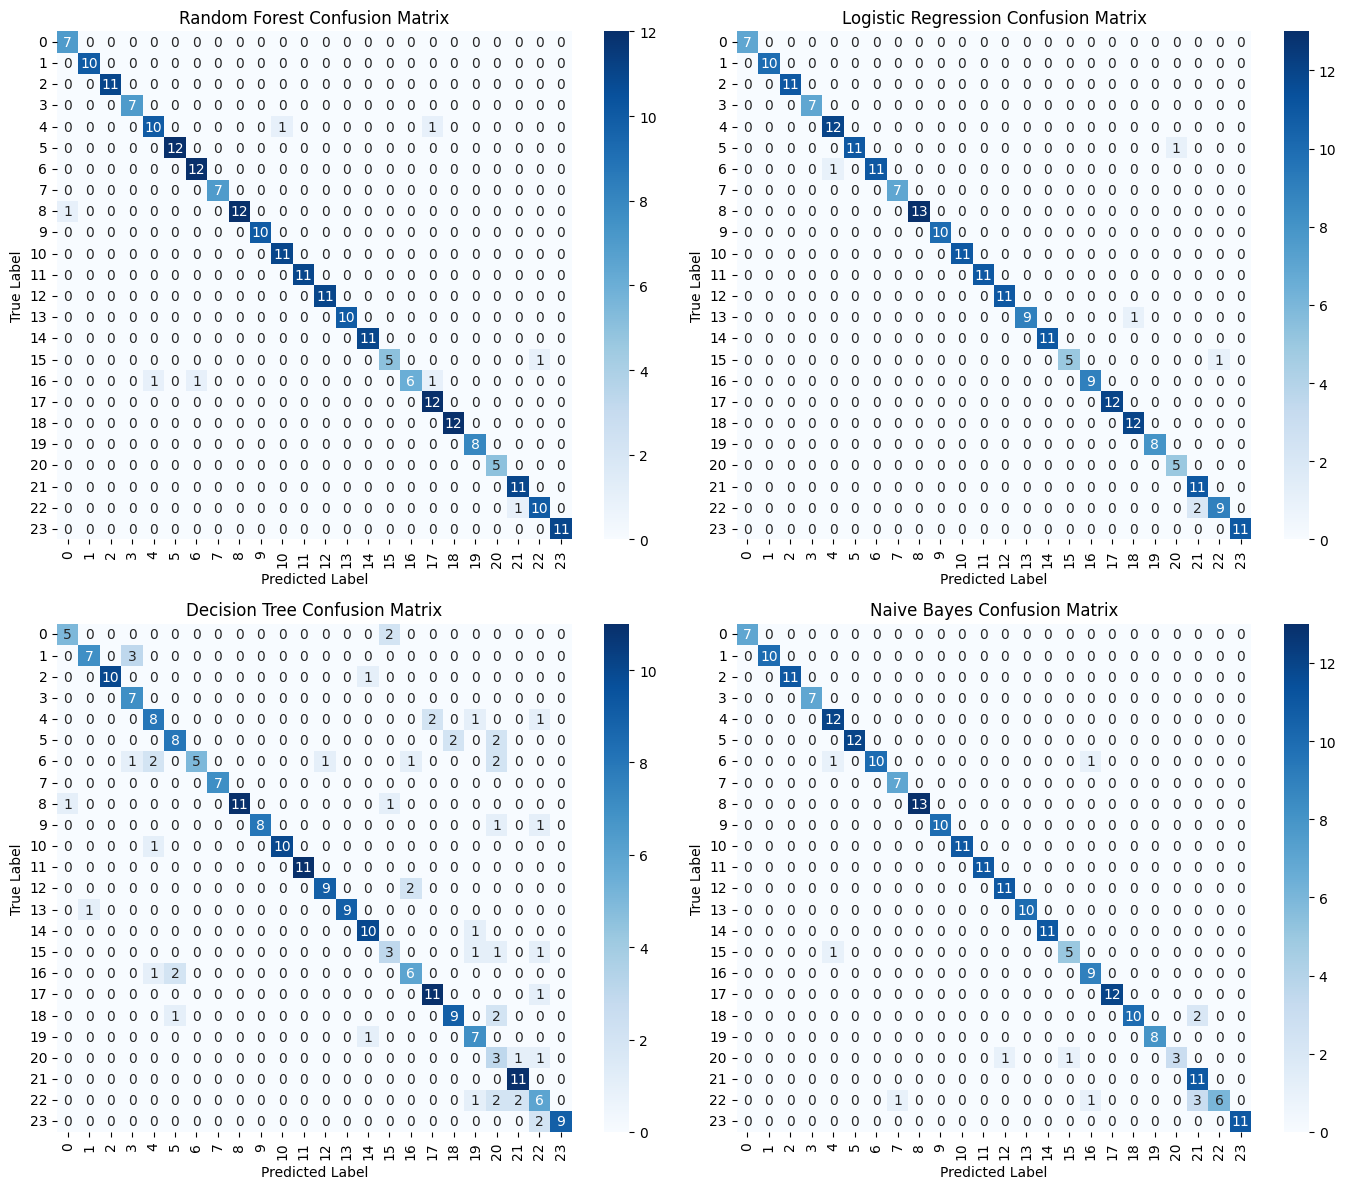

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, clf) in enumerate(models.items()):
    y_pred = clf.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

                     Precision    Recall        F1
Random Forest         0.969014  0.966667  0.965596
Logistic Regression   0.977201  0.975000  0.974925
Decision Tree         0.832368  0.791667  0.799298
Naive Bayes           0.960084  0.950000  0.948033


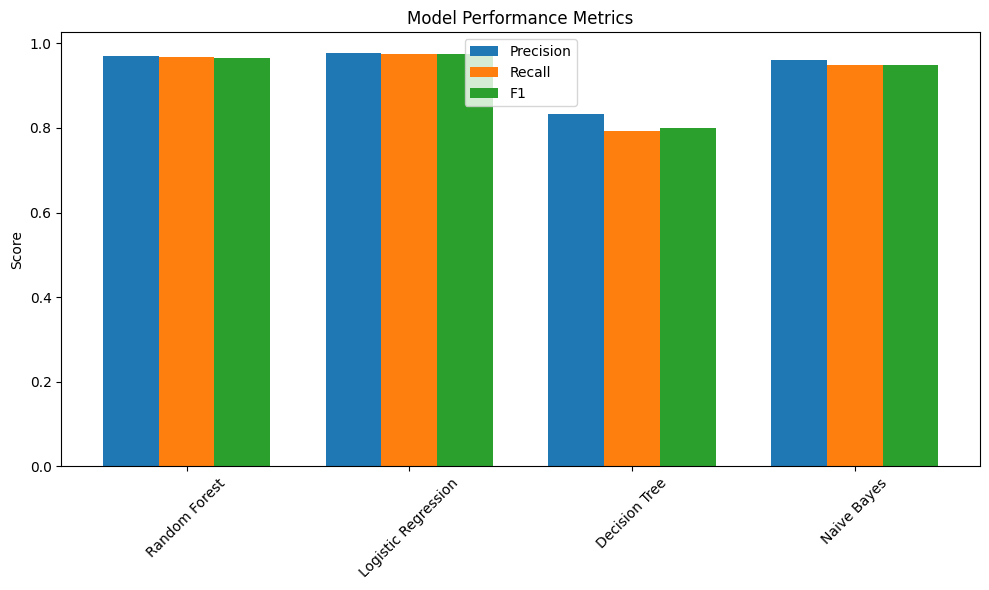

In [59]:
metrics = {'Precision': [], 'Recall': [], 'F1': []}
model_names = []

for name, clf in models.items():
    y_pred = clf.predict(X_test_tfidf)
    model_names.append(name)
    metrics['Precision'].append(precision_score(y_test, y_pred, average='weighted'))
    metrics['Recall'].append(recall_score(y_test, y_pred, average='weighted'))
    metrics['F1'].append(f1_score(y_test, y_pred, average='weighted'))

df = pd.DataFrame(metrics, index=model_names)
print(df)

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(model_names))
width = 0.25
ax.bar([i - width for i in x], metrics['Precision'], width, label='Precision')
ax.bar(x, metrics['Recall'], width, label='Recall')
ax.bar([i + width for i in x], metrics['F1'], width, label='F1')
ax.set_ylabel('Score')
ax.set_title('Model Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()